Basado en: https://universe.roboflow.com/project-uyrxf/ppe_detection-v1x3l

#**Paso 01: Clonar el repositorio**

In [ ]:
!git clone https://github.com/WongKinYiu/yolov9.git

Cloning into 'yolov9'...
remote: Enumerating objects: 778, done.
remote: Counting objects: 100% (404/404), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 778 (delta 278), reused 277 (delta 227), pack-reused 374
Receiving objects: 100% (778/778), 3.30 MiB | 6.37 MiB/s, done.
Resolving deltas: 100% (323/323), done.


#**Paso 02: Cambiar el directorio**

In [ ]:
%cd yolov9

/content/yolov9


#**Paso 03: Instalar los paquetes requeridos**

In [ ]:
!pip install -r requirements.txt -q

#**Paso 04: Descargar los pesos**

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content/yolov9


In [ ]:
!mkdir -p {HOME}/weights

In [ ]:
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-e.pt

In [ ]:
!ls -la {HOME}/weights

total 475344
drwxr-xr-x  2 root root      4096 Jun 14 15:41 .
drwxr-xr-x 14 root root      4096 Jun 14 15:41 ..
-rw-r--r--  1 root root 103153312 Feb 18 12:36 yolov9-c.pt
-rw-r--r--  1 root root 103153312 Feb 18 12:36 yolov9-c.pt.1
-rw-r--r--  1 root root 140217688 Feb 18 12:36 yolov9-e.pt
-rw-r--r--  1 root root 140217688 Feb 18 12:36 yolov9-e.pt.1


#**Paso 05: Descargar el dataset de Roboflow**

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="xXjYkapaMmqpwBFaLENS")
project = rf.workspace("pc3").project("shopping-cart-z4cff")
version = project.version(1)
dataset = version.download("yolov9")


loading Roboflow workspace...
loading Roboflow project...


#**Paso 06: Entrenar el modelo**

In [ ]:
%cd yolov9

[Errno 2] No such file or directory: 'yolov9'
/content/yolov9


In [ ]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!python train_dual.py --workers 8 --device 0 --batch 8 --data 'shopping-cart-1/data.yaml' --img 640 --cfg models/detect/yolov9-e.yaml --weights '{HOME}/weights/yolov9-e.pt' --name yolov9-e-finetuning --hyp hyp.scratch-high.yaml --min-items 0 --epochs 25 --close-mosaic 15


2024-06-14 15:48:08.474530: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-14 15:48:08.474618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-14 15:48:08.480229: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-06-14 15:48:08.507992: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-14 15:48:11.000341: W tensorflow/compiler/tf2

#**Descargar los pesos Weights From the Drive**

In [ ]:
# !gdown 1DZos6dpApSOWf3ZeFn-WFLpAslXbMvNo

In [ ]:
!gdown "https://drive.google.com/uc?id=140oaWpcxsbZM9glqzeUYHR5gQT_wERX6&confirm=t" #probar

Downloading...
From: https://drive.google.com/uc?id=140oaWpcxsbZM9glqzeUYHR5gQT_wERX6&confirm=t
To: /content/yolov9/best.pt
100% 140M/140M [00:00<00:00, 226MB/s]


##**Paso 07: Examinar los resultados**

**NOTE:** Por defecto, los resultados están guardados en: `{HOME}/yolov9/runs/train/`, in llamados... `exp`, `exp2`, `exp3`, ... Esto se puede cambiar con el parámetro `--name`.

In [ ]:
!ls {HOME}/runs/train/yolov9-e-finetuning4/

ls: cannot access '/content/yolov9/runs/train/yolov9-e-finetuning4/': No such file or directory


In [ ]:
from IPython.display import Image

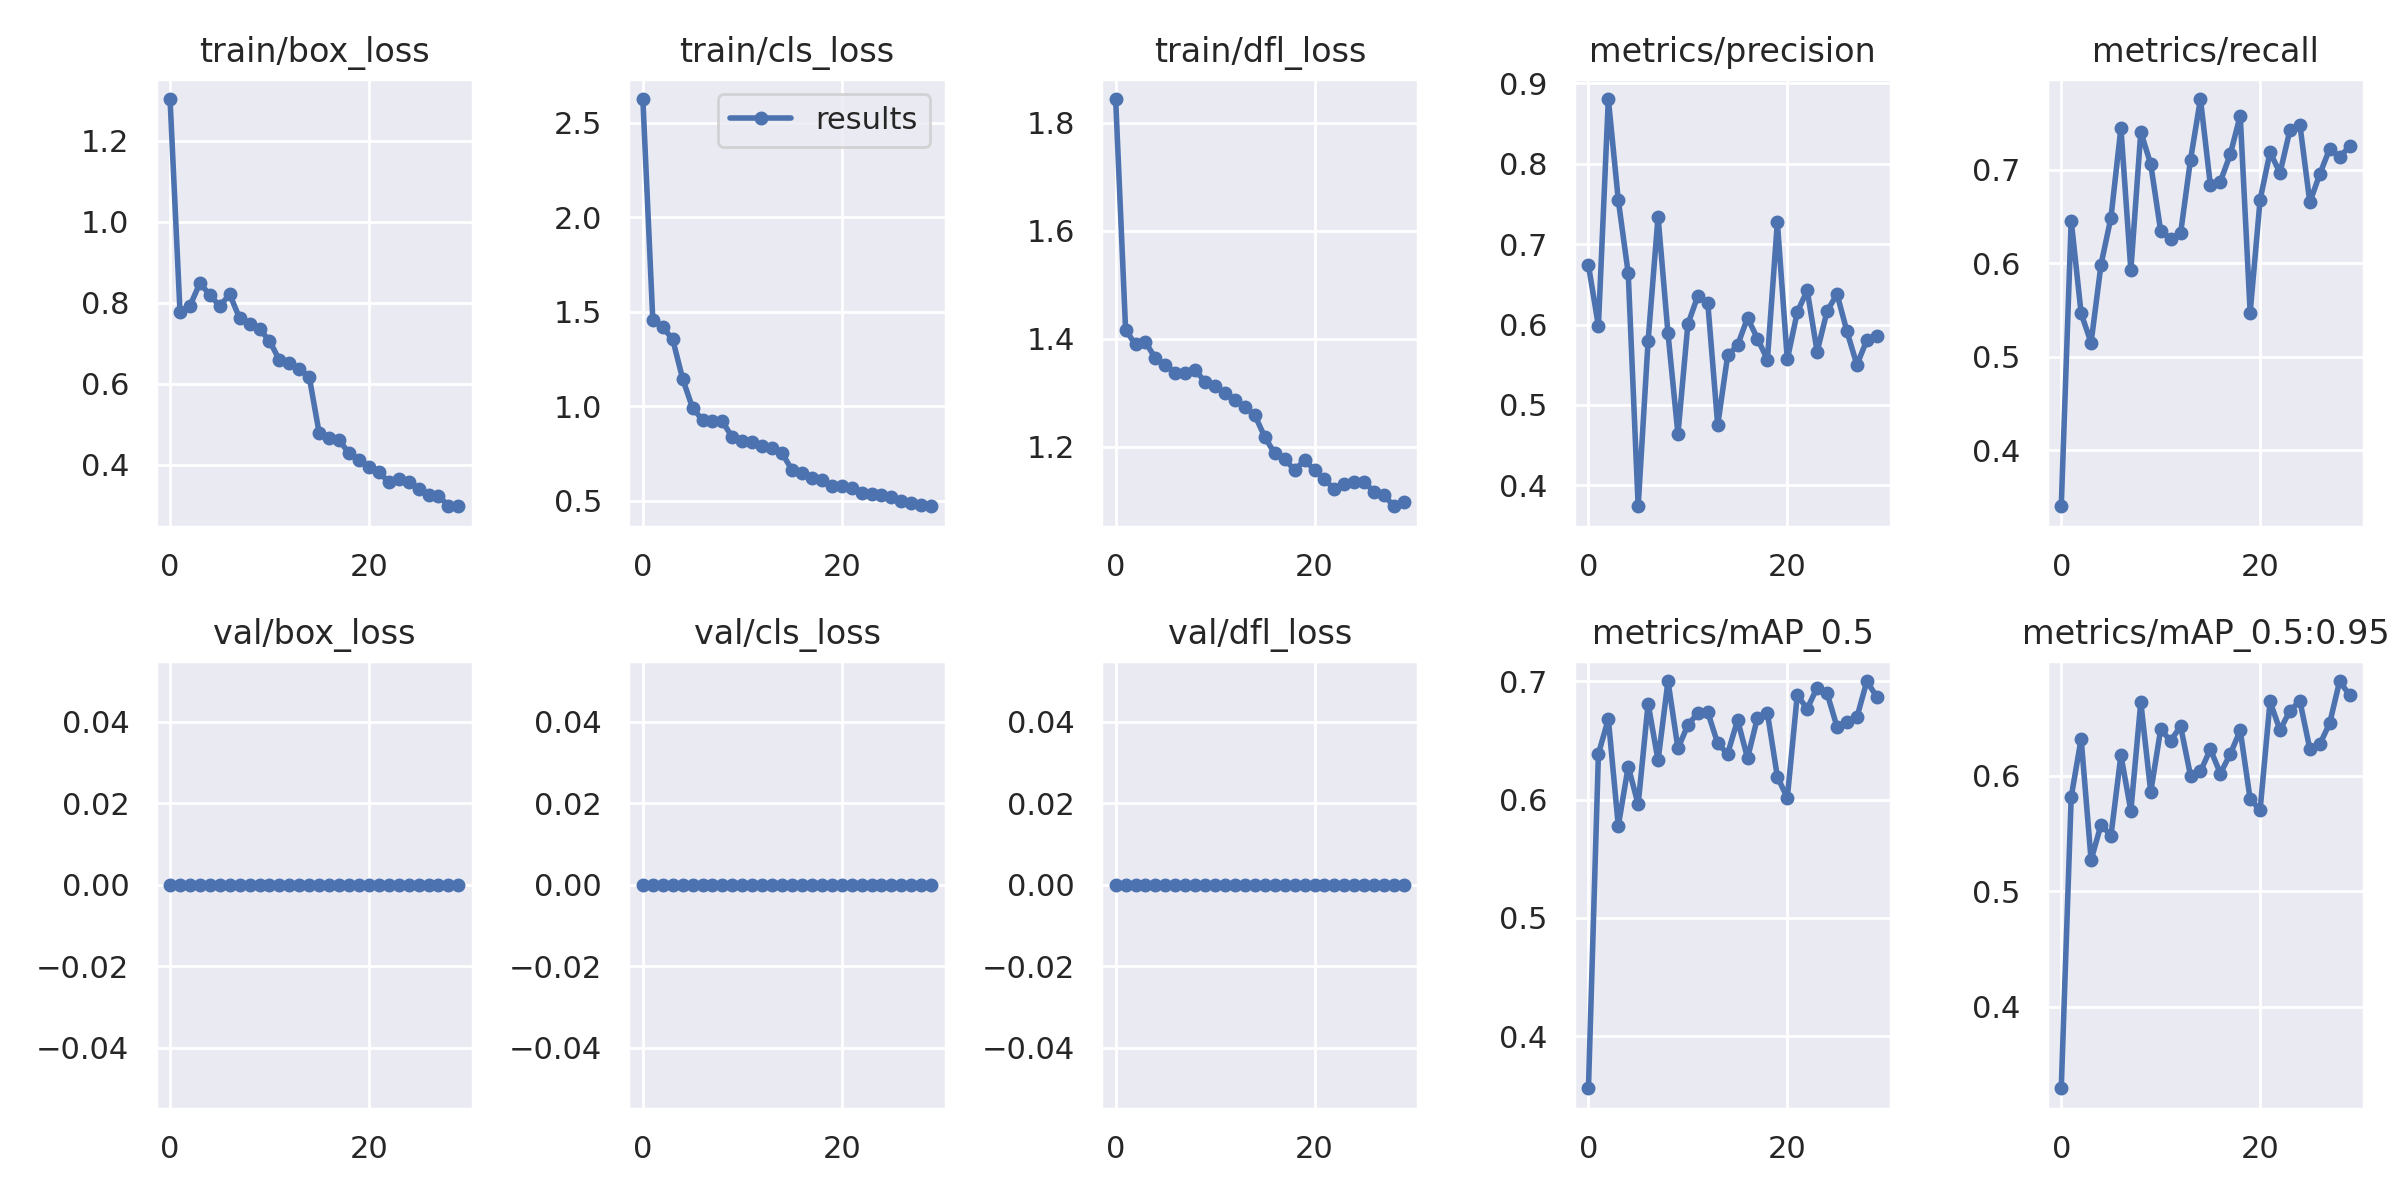

In [ ]:
Image(filename=f"{HOME}/runs/train/yolov9-e-finetuning/results.png", width=1000)

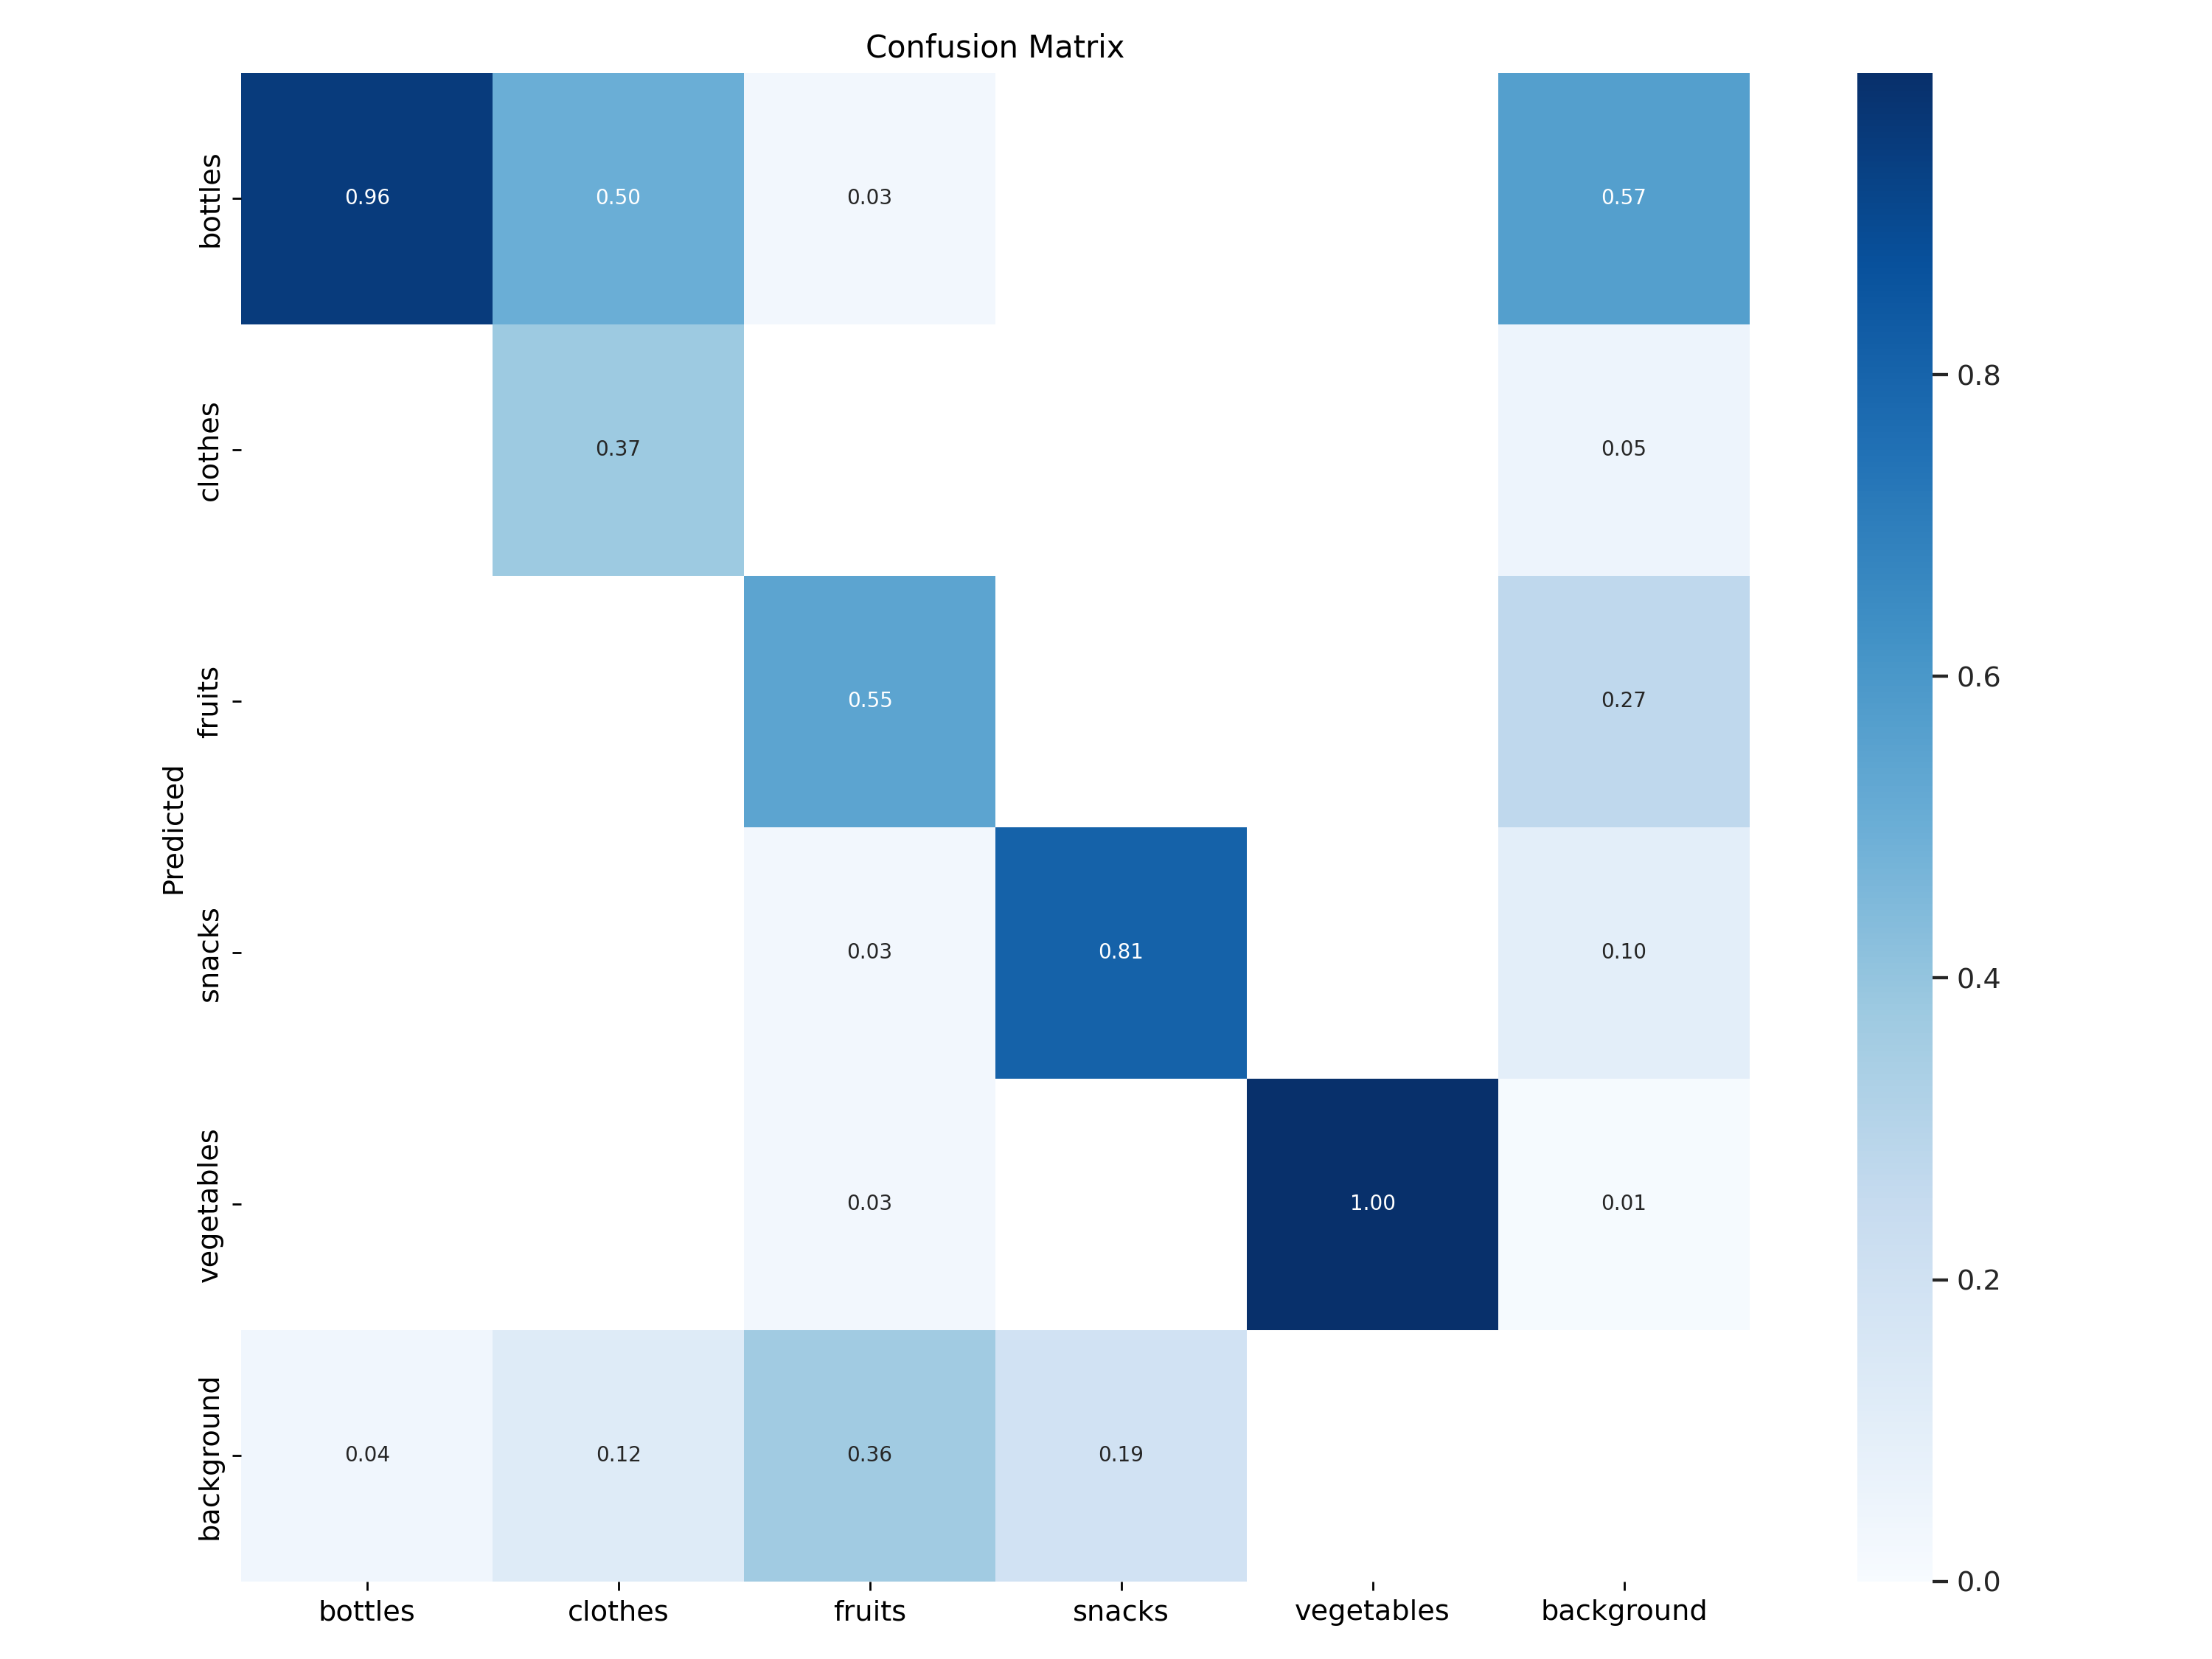

In [ ]:
Image(filename=f"{HOME}/runs/train/yolov9-e-finetuning/confusion_matrix.png", width=1000)

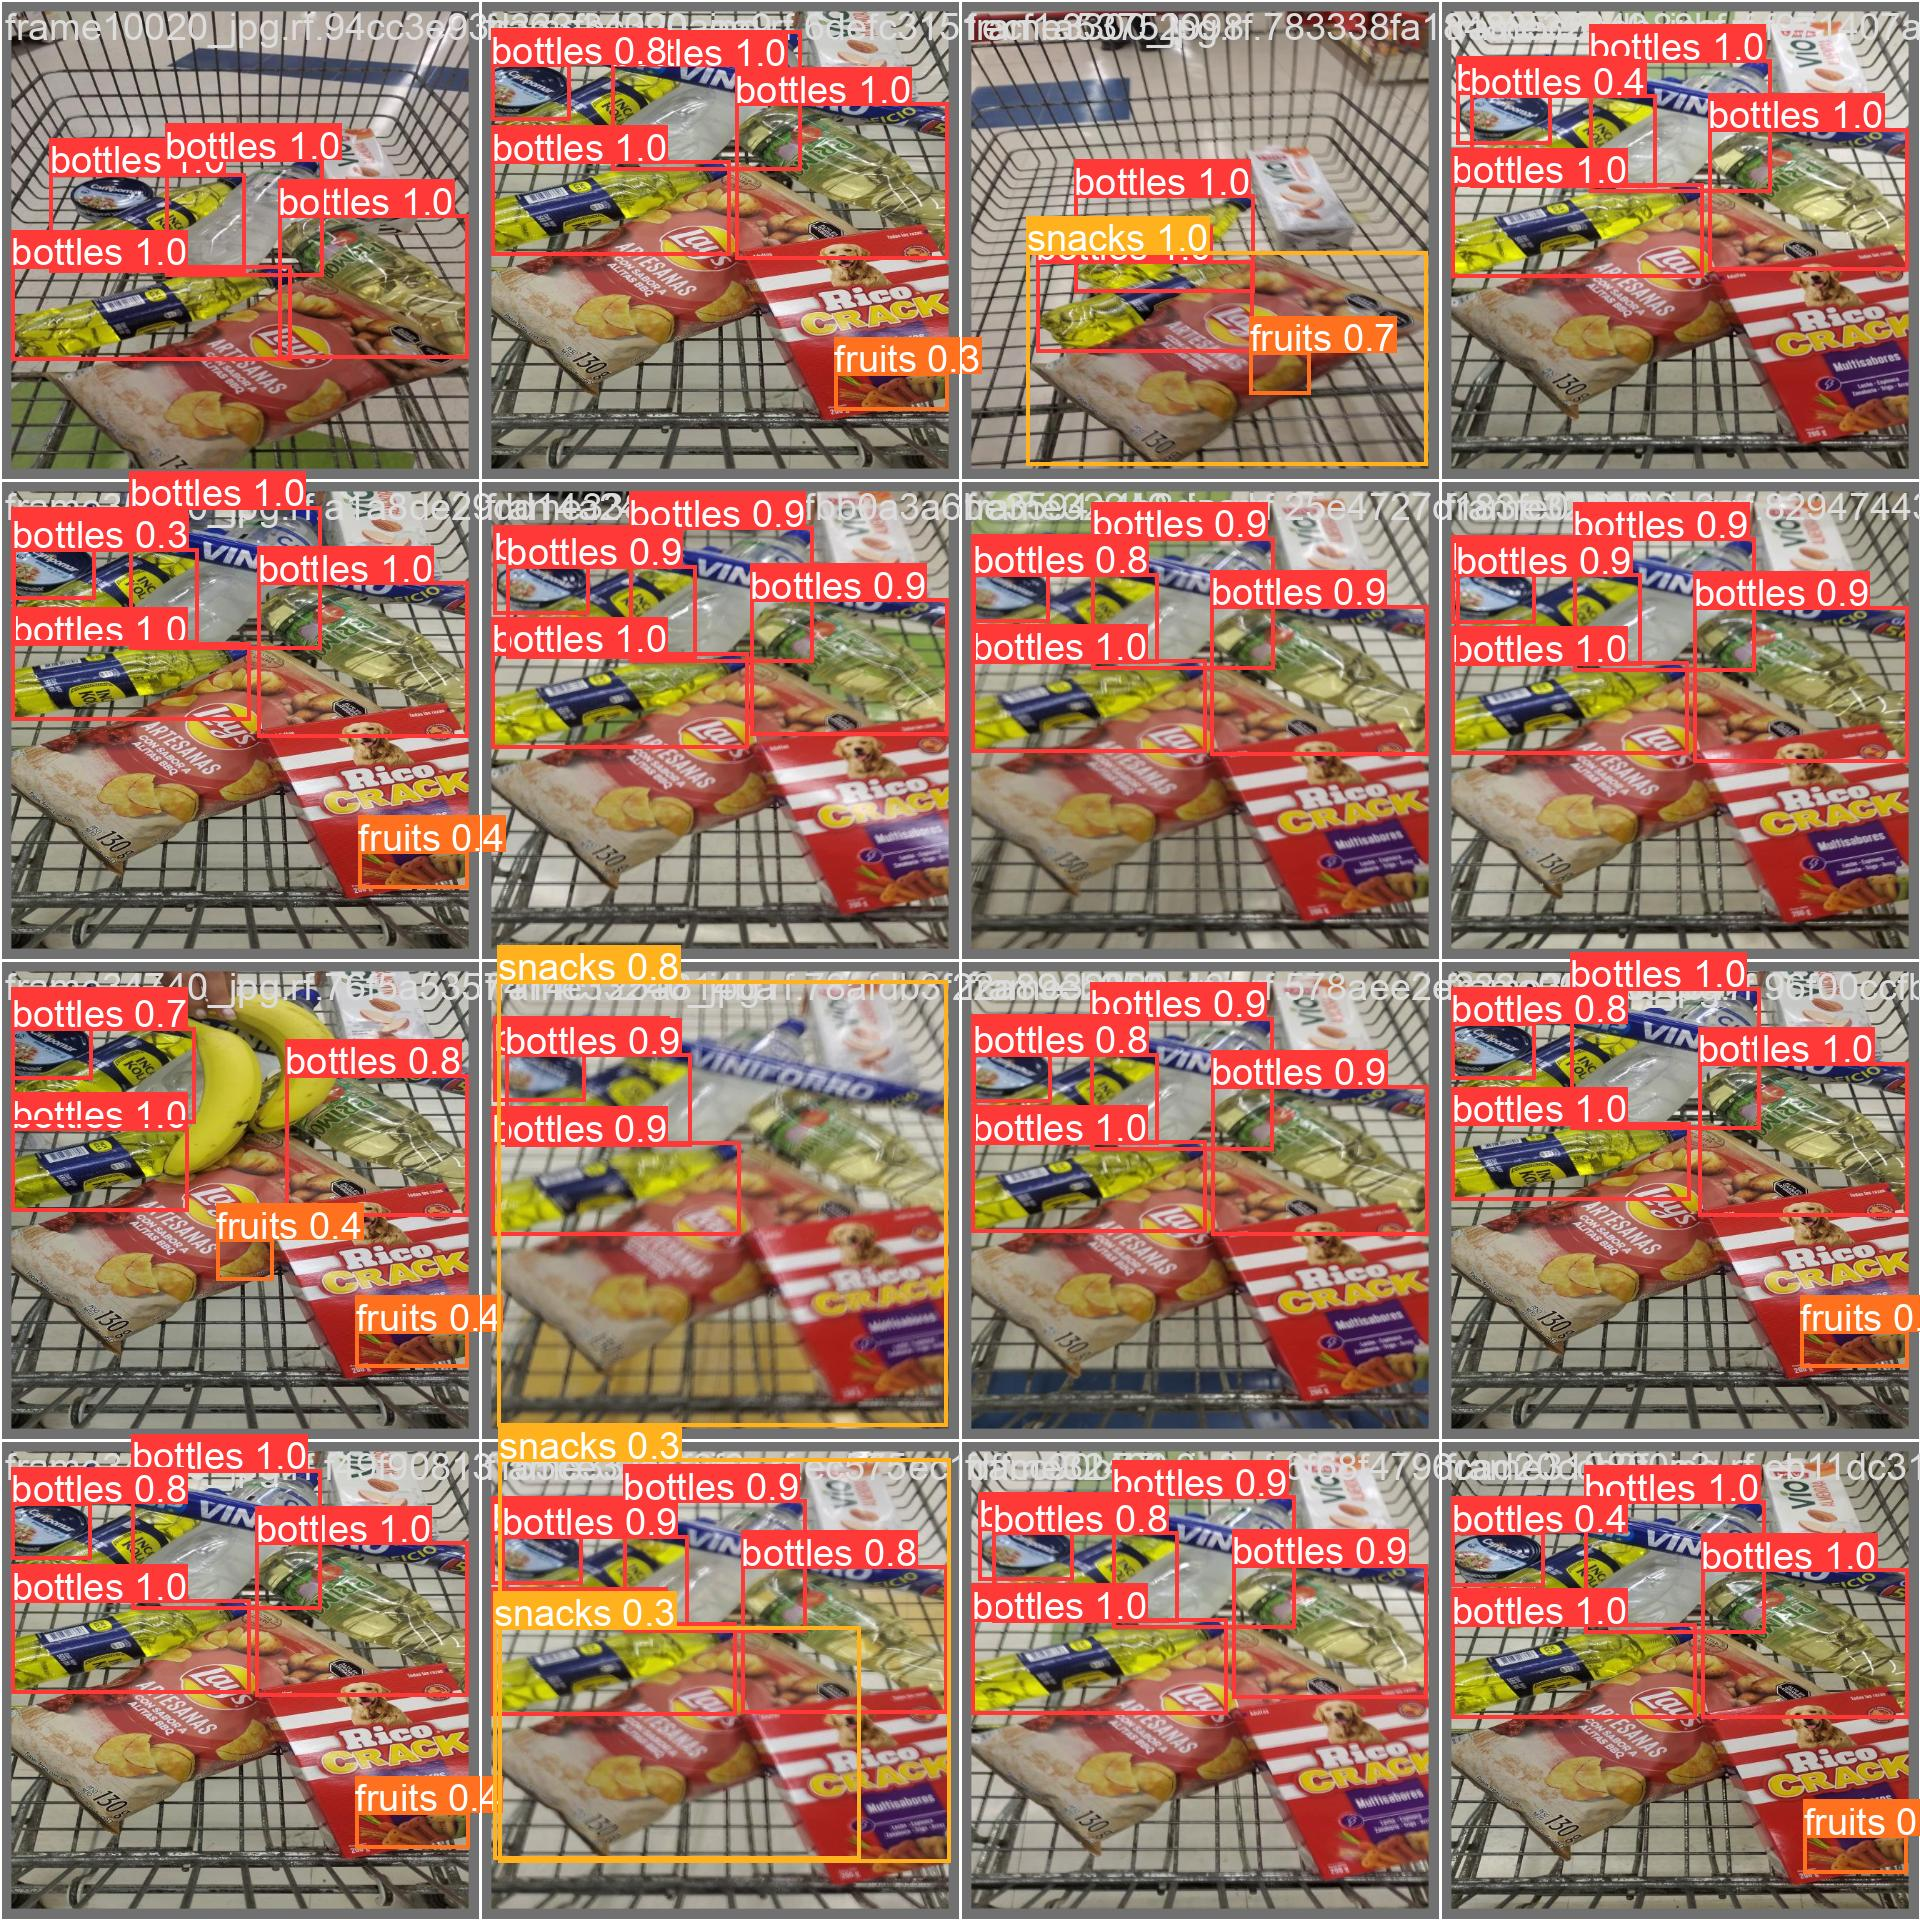

In [ ]:
Image(filename=f"{HOME}/runs/train/yolov9-e-finetuning/val_batch0_pred.jpg", width=1000)

#**Paso 08: Validando el modelol**

In [ ]:
# evaluate yolov9 models
!python val_dual.py --data 'shopping-cart-1/data.yaml' --img 640 --batch 16 --conf 0.001 --iou 0.7 --device 0 --weights 'runs/train/yolov9-e-finetuning/weights/best.pt' --save-json --name yolov9_ppe_c_640_val


val_dual: data=shopping-cart-1/data.yaml, weights=['runs/train/yolov9-e-finetuning/weights/best.pt'], batch_size=16, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=True, project=runs/val, name=yolov9_ppe_c_640_val, exist_ok=False, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
yolov9-e summary: 839 layers, 68553982 parameters, 0 gradients, 240.7 GFLOPs
val: Scanning /content/yolov9/shopping-cart-1/valid/labels.cache... 129 images, 0 backgrounds, 0 corrupt: 100% 129/129 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 9/9 [00:14<00:00,  1.66s/it]
                   all        129        540      0.581      0.713      0.699      0.681
               bottles        129        465      0.

#**Paso 09: Descargar los videos demo**

In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1SfyEtRXX2Mtmvs0WoTdVUTrOU_1YX67D/view?usp=sharing"

Downloading...
From (original): https://drive.google.com/uc?id=1SfyEtRXX2Mtmvs0WoTdVUTrOU_1YX67D
From (redirected): https://drive.google.com/uc?id=1SfyEtRXX2Mtmvs0WoTdVUTrOU_1YX67D&confirm=t&uuid=f446baad-5eac-48d2-acd6-a4247621de71
To: /content/yolov9/20240613_162147.mp4
100% 5.94G/5.94G [00:54<00:00, 110MB/s] 


#**Paso 10: Inferencia en imagen**

In [ ]:
!pwd

/content/yolov9


In [ ]:
# inference yolov9 models
!python detect_dual.py --source 'shopping-cart-1/valid/images/frame22200_jpg.rf.56782ad12ac30be808d9dadacbe1ad42.jpg' --img 640 --device 0 --weights 'runs/train/yolov9-e-finetuning/weights/best.pt' --name yolov9_c_ppe_640_detect


detect_dual: weights=['runs/train/yolov9-e-finetuning/weights/best.pt'], source=shopping-cart-1/valid/images/frame22200_jpg.rf.56782ad12ac30be808d9dadacbe1ad42.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=yolov9_c_ppe_640_detect, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
yolov9-e summary: 839 layers, 68553982 parameters, 0 gradients, 240.7 GFLOPs
image 1/1 /content/yolov9/shopping-cart-1/valid/images/frame22200_jpg.rf.56782ad12ac30be808d9dadacbe1ad42.jpg: 640x640 4 bottless, 103.1ms
Speed: 0.6ms pre-process, 103.1ms inference, 768.1ms NMS per image at shape (1, 3, 640, 640)
Resul

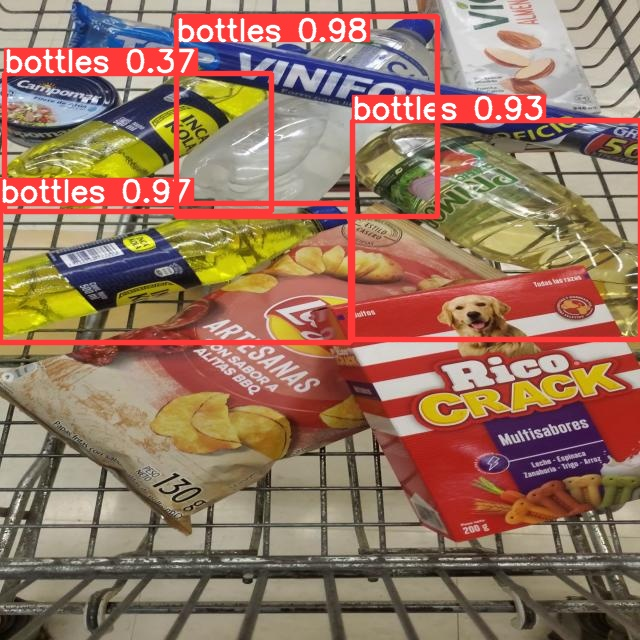

In [ ]:
Image(filename=f"{HOME}/runs/detect/yolov9_c_ppe_640_detect4/frame22200_jpg.rf.56782ad12ac30be808d9dadacbe1ad42.jpg")

#**Paso 11: Inferencia en video**

In [ ]:
# inference yolov9 models
!python detect_dual.py --source '20240613_162147.mp4' --img 640 --device 0 --weights 'runs/train/yolov9-e-finetuning/weights/best.pt' --name yolov9_ppe_640_detect


detect_dual: weights=['runs/train/yolov9-e-finetuning/weights/best.pt'], source=20240613_162147.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=yolov9_ppe_640_detect, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
yolov9-e summary: 839 layers, 68553982 parameters, 0 gradients, 240.7 GFLOPs
video 1/1 (1/39010) /content/yolov9/20240613_162147.mp4: 640x384 (no detections), 227.0ms
video 1/1 (2/39010) /content/yolov9/20240613_162147.mp4: 640x384 (no detections), 64.4ms
video 1/1 (3/39010) /content/yolov9/20240613_162147.mp4: 640x384 (no detections), 64.3ms
video 1/1 (4/39010) /content/yolov9

#**Mostrando el video**

In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = '/content/yolov9/20240613_162147.mp4'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

In [ ]:
# inference yolov9 models
!python detect_dual.py --source 'PPE_Part2.mp4' --img 640 --device 0 --weights 'best.pt' --name yolov9_ppe_640_detect2
